# dualtrain_multisession — 640×480 output

Same architecture as `dualtrain_multisession.ipynb` but trains and infers at the
native camera resolution **640 × 480** instead of 128 × 128.

Key differences from the 128-px version:
- `OUT_H = 480`, `OUT_W = 640` replace the single `IMAGE_SIZE`.
- The decoder still upsamples from 8×8 to a square power-of-2 (`DECODER_SIZE`,
  default 256), then `F.interpolate` stretches to the exact (480, 640) target.
- `BATCH_SIZE` is set to 4 by default (18× more pixels per sample).
- Checkpoint directory is `checkpoints_multisession_640x480` to avoid collisions.

## 0. Environment setup — Kaggle dataset, deps, GPU

>Change runtime type → **GPU** before running.

In [1]:
IN_COLAB = False
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass
print('In Colab:', IN_COLAB)

In Colab: True


In [2]:
import importlib, subprocess, sys

def _ensure(pkg, import_name=None):
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg, mod in [
    ('kagglehub', 'kagglehub'),
    ('pyyaml', 'yaml'),
    ('opencv-python-headless', 'cv2'),
    ('scikit-learn', 'sklearn'),
    ('scipy', 'scipy'),
    ('tqdm', 'tqdm'),
]:
    _ensure(pkg, mod)

In [3]:
import kagglehub
import shutil
from pathlib import Path as _Path

KAGGLE_DATASET = 'supphasansaithong/mani-recognition'
TARGET_PATH    = '/content' if IN_COLAB else str(_Path.home() / 'mani-recognition')

if IN_COLAB:
    _dl_path = kagglehub.dataset_download(KAGGLE_DATASET)
    print('Path to dataset files:', _dl_path)
    _Path(TARGET_PATH).mkdir(parents=True, exist_ok=True)
    shutil.copytree(_dl_path, TARGET_PATH, dirs_exist_ok=True)
    print(f'Files copied to: {TARGET_PATH}')
else:
    print('Not in Colab — skipping Kaggle download. Set SESSION_ROOTS manually in the config cell.')

100%|██████████| 132M/132M [00:07<00:00, 18.9MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/supphasansaithong/mani-recognition/versions/3
Files copied to: /content


In [4]:
import os

def _listdir_safe(p, limit=40):
    try:
        return sorted(os.listdir(p))[:limit]
    except FileNotFoundError:
        return []

if IN_COLAB:
    print('Top level:', _listdir_safe(TARGET_PATH))
    for name in _listdir_safe(TARGET_PATH):
        sub = os.path.join(TARGET_PATH, name)
        if os.path.isdir(sub):
            print(f'  {name}/ ->', _listdir_safe(sub, 20))

Top level: ['.config', 'checkpoints_multisession_640x480', 'requirements.txt', 'sample_data', 'session_test', 'session_train1', 'session_train2']
  .config/ -> ['.last_opt_in_prompt.yaml', '.last_survey_prompt.yaml', '.last_update_check.json', 'active_config', 'config_sentinel', 'configurations', 'default_configs.db', 'gce', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'logs']
  checkpoints_multisession_640x480/ -> ['best_multisession_640x480.pth', 'latest_multisession_640x480.pth', 'training_history_multisession_640x480.json']
  sample_data/ -> ['README.md', 'anscombe.json', 'california_housing_test.csv', 'california_housing_train.csv', 'mnist_test.csv', 'mnist_train_small.csv']
  session_test/ -> ['session_test']
  session_train1/ -> ['session_train1']
  session_train2/ -> ['session_train2']


In [5]:
from pathlib import Path

# ========= Sessions to combine for training =========
if IN_COLAB:
    SESSION_ROOTS = [
        Path('/content/session_train1/session_train1'),
        Path('/content/session_train2/session_train2'),
    ]
    CHECKPOINT_DIR = Path('/content/checkpoints_multisession_640x480')
else:
    SESSION_ROOTS = [
        Path("/home/bozznyskrtt/pcl_ws/teddybear/session_train1"),
        Path("/home/bozznyskrtt/pcl_ws/teddybear/session_train2"),
    ]
    CHECKPOINT_DIR = Path("checkpoints_multisession_640x480")

# ========= Output resolution =========
OUT_H = 480   # height
OUT_W = 640   # width

# Decoder internally upsamples to DECODER_SIZE×DECODER_SIZE (must be power-of-2
# and in [64, 128, 256, 512]), then interpolates to (OUT_H, OUT_W).
DECODER_SIZE = 256

# ========= Training =========
BATCH_SIZE    = 4      # reduced — 640×480 is ~18× larger than 128×128
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
VAL_RATIO     = 0.2
SEED          = 42
NUM_WORKERS   = 4
PREVIEW_SAMPLES = 10

# ========= Checkpoint =========
RESUME            = False
RESUME_CHECKPOINT = CHECKPOINT_DIR / "best_multisession_640x480.pth" if RESUME else None
STRICT_LOAD       = RESUME
FINE_TUNE         = RESUME
FREEZE_MLP            = RESUME
FREEZE_SHARED_DECODER = RESUME
EARLY_STOP_PATIENCE   = 20

# ========= Input features =========
SELECTED_JOINTS = [
    "J1_base",
    "J2_shoulder",
    "J3_elbow",
    "J4_wrist1",
    "J5_wrist2",
    "J6_wrist3",
    "end_effector_1/input_l_finger",
]
USE_VELOCITIES   = True
USE_EFFORTS      = True
USE_T_CAM_TO_EE  = True
USE_T_BASE_TO_EE = True

# ========= Depth =========
DEPTH_NORM_MODE = "global"
DEPTH_MAX_MM    = 1000.0

# ========= Loss weights =========
MASK_LOSS_WEIGHT  = 5.0
DEPTH_LOSS_WEIGHT = 20.0

# ========= Device =========
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"

print("Sessions:", [str(s) for s in SESSION_ROOTS])
print(f"Output resolution : {OUT_W}×{OUT_H}")
print(f"Decoder size      : {DECODER_SIZE}×{DECODER_SIZE} → interpolate to {OUT_W}×{OUT_H}")
print("DEVICE:", DEVICE)

Sessions: ['/content/session_train1/session_train1', '/content/session_train2/session_train2']
Output resolution : 640×480
Decoder size      : 256×256 → interpolate to 640×480
DEVICE: cuda


In [6]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import cv2
import yaml
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

In [7]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [8]:
def safe_float(x) -> float:
    try:
        v = float(x)
        if math.isnan(v) or math.isinf(v):
            return 0.0
        return v
    except Exception:
        return 0.0


def flatten_matrix(mat, expected_shape: Tuple[int, int] = (4, 4)) -> List[float]:
    if mat is None:
        return [0.0] * (expected_shape[0] * expected_shape[1])
    arr = np.asarray(mat, dtype=np.float32)
    if arr.shape != expected_shape:
        out = np.zeros(expected_shape, dtype=np.float32)
        h = min(expected_shape[0], arr.shape[0])
        w = min(expected_shape[1], arr.shape[1])
        out[:h, :w] = arr[:h, :w]
        arr = out
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr.reshape(-1).tolist()


def load_yaml_meta(meta_path) -> Dict:
    with open(meta_path, "r", encoding="utf-8") as f:
        text = f.read()
    text = text.replace(": nan", ": .nan")
    data = yaml.safe_load(text)
    if not isinstance(data, dict):
        raise ValueError(f"Failed to parse metadata file: {meta_path}")
    if "captures" not in data or not isinstance(data["captures"], list):
        raise ValueError("meta.txt must contain a top-level 'captures' list.")
    return data


def resize_hw(img: np.ndarray, h: int, w: int) -> np.ndarray:
    """Resize to (h, w) with nearest-neighbour — cv2 takes (width, height)."""
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_NEAREST).astype(np.float32)


def depth_to_mask(depth_img: np.ndarray) -> np.ndarray:
    if depth_img.ndim == 3:
        depth_img = depth_img[..., 0]
    return (depth_img > 0).astype(np.float32)


def normalize_depth(depth_img: np.ndarray, mode: str = "per_image",
                    global_max_mm: float = 3000.0) -> np.ndarray:
    depth = depth_img.astype(np.float32)
    if depth.ndim == 3:
        depth = depth[..., 0]
    valid = depth > 0
    out   = np.zeros_like(depth, dtype=np.float32)
    if not np.any(valid):
        return out
    if mode == "per_image":
        dmax = depth[valid].max()
        if dmax > 0:
            out[valid] = depth[valid] / dmax
    elif mode == "global":
        out[valid] = depth[valid] / float(global_max_mm)
        out = np.clip(out, 0.0, 1.0)
    else:
        raise ValueError(f"Unknown DEPTH_NORM_MODE: {mode}")
    return out

In [9]:
@dataclass
class SampleRecord:
    image_path: str
    feature_vec: np.ndarray
    seq: int
    session_name: str


class RobotArmMaskDepthDataset(Dataset):
    """Single-session dataset — images resized to (out_h, out_w)."""

    def __init__(
        self,
        dataset_root,
        meta_path,
        out_h: int = 480,
        out_w: int = 640,
        selected_joints: Optional[List[str]] = None,
        use_velocities: bool = False,
        use_efforts: bool = False,
        use_t_cam_to_ee: bool = False,
        use_t_base_to_ee: bool = False,
        depth_norm_mode: str = "per_image",
        depth_max_mm: float = 3000.0,
        session_name: str = "",
    ) -> None:
        super().__init__()
        self.dataset_root    = str(dataset_root)
        self.meta            = load_yaml_meta(meta_path)
        self.out_h           = out_h
        self.out_w           = out_w
        self.use_velocities  = use_velocities
        self.use_efforts     = use_efforts
        self.use_t_cam_to_ee  = use_t_cam_to_ee
        self.use_t_base_to_ee = use_t_base_to_ee
        self.depth_norm_mode = depth_norm_mode
        self.depth_max_mm    = depth_max_mm
        self.session_name    = session_name

        captures = self.meta["captures"]
        if len(captures) == 0:
            raise ValueError("No captures found in metadata.")

        if selected_joints is None:
            selected_joints = list(captures[0]["joint_names"])
        self.selected_joints = selected_joints

        self.records: List[SampleRecord] = []
        for cap in captures:
            rec = self._build_record(cap)
            if rec is not None:
                self.records.append(rec)

        if len(self.records) == 0:
            raise ValueError("No valid samples found.")

        self.feature_dim = self.records[0].feature_vec.shape[0]

    def _build_joint_feature(self, joint_names, joint_positions,
                              joint_velocities, joint_efforts) -> np.ndarray:
        name_to_idx = {name: i for i, name in enumerate(joint_names)}
        feats: List[float] = []

        for jn in self.selected_joints:
            idx = name_to_idx.get(jn)
            feats.append(safe_float(joint_positions[idx]) if idx is not None else 0.0)

        if self.use_velocities:
            vals = joint_velocities or []
            for jn in self.selected_joints:
                idx = name_to_idx.get(jn)
                feats.append(safe_float(vals[idx]) if idx is not None and idx < len(vals) else 0.0)

        if self.use_efforts:
            vals = joint_efforts or []
            for jn in self.selected_joints:
                idx = name_to_idx.get(jn)
                feats.append(safe_float(vals[idx]) if idx is not None and idx < len(vals) else 0.0)

        return np.asarray(feats, dtype=np.float32)

    def _build_record(self, cap: Dict) -> Optional[SampleRecord]:
        depth_png = cap.get("depth_png")
        if not depth_png:
            return None

        image_path = os.path.join(self.dataset_root, depth_png)
        if not os.path.exists(image_path):
            print(f"[WARN] Missing image: {image_path}")
            return None

        feature_vec = self._build_joint_feature(
            joint_names=cap.get("joint_names", []),
            joint_positions=cap.get("joint_positions", []),
            joint_velocities=cap.get("joint_velocities", []),
            joint_efforts=cap.get("joint_efforts", []),
        )

        extra: List[float] = []
        if self.use_t_cam_to_ee:
            extra.extend(flatten_matrix(cap.get("T_cam_to_ee")))
        if self.use_t_base_to_ee:
            extra.extend(flatten_matrix(cap.get("T_base_to_ee")))
        if extra:
            feature_vec = np.concatenate([feature_vec, np.asarray(extra, dtype=np.float32)])

        return SampleRecord(
            image_path=image_path,
            feature_vec=feature_vec,
            seq=int(cap.get("seq", -1)),
            session_name=self.session_name,
        )

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        rec = self.records[idx]

        depth_raw = np.array(Image.open(rec.image_path))
        if depth_raw.ndim == 3:
            depth_raw = depth_raw[..., 0]

        mask  = depth_to_mask(depth_raw)
        depth = normalize_depth(depth_raw, mode=self.depth_norm_mode,
                                global_max_mm=self.depth_max_mm)

        # Resize to target resolution (h, w)
        mask  = resize_hw(mask,  self.out_h, self.out_w)
        depth = resize_hw(depth, self.out_h, self.out_w)

        x       = torch.from_numpy(rec.feature_vec).float()
        y_mask  = torch.from_numpy(mask).float().unsqueeze(0)
        y_depth = torch.from_numpy(depth).float().unsqueeze(0)
        return x, y_mask, y_depth

In [10]:
session_datasets = []

for root in SESSION_ROOTS:
    ds = RobotArmMaskDepthDataset(
        dataset_root=root / "crop",
        meta_path=root / "meta.txt",
        out_h=OUT_H,
        out_w=OUT_W,
        selected_joints=SELECTED_JOINTS,
        use_velocities=USE_VELOCITIES,
        use_efforts=USE_EFFORTS,
        use_t_cam_to_ee=USE_T_CAM_TO_EE,
        use_t_base_to_ee=USE_T_BASE_TO_EE,
        depth_norm_mode=DEPTH_NORM_MODE,
        depth_max_mm=DEPTH_MAX_MM,
        session_name=root.name,
    )
    print(f"{root.name}: {len(ds)} samples, feature_dim={ds.feature_dim}")
    session_datasets.append(ds)

dims = {ds.feature_dim for ds in session_datasets}
assert len(dims) == 1, f"Feature dim mismatch across sessions: {dims}"
FEATURE_DIM = dims.pop()

dataset = ConcatDataset(session_datasets)
print(f"\nCombined dataset: {len(dataset)} samples, feature_dim={FEATURE_DIM}")

session_train1: 112 samples, feature_dim=53
session_train2: 214 samples, feature_dim=53

Combined dataset: 326 samples, feature_dim=53


x shape   : torch.Size([53])
mask shape : torch.Size([1, 480, 640])  min/max: 0.0 1.0
depth shape: torch.Size([1, 480, 640])  min/max: 0.0 0.44600000977516174


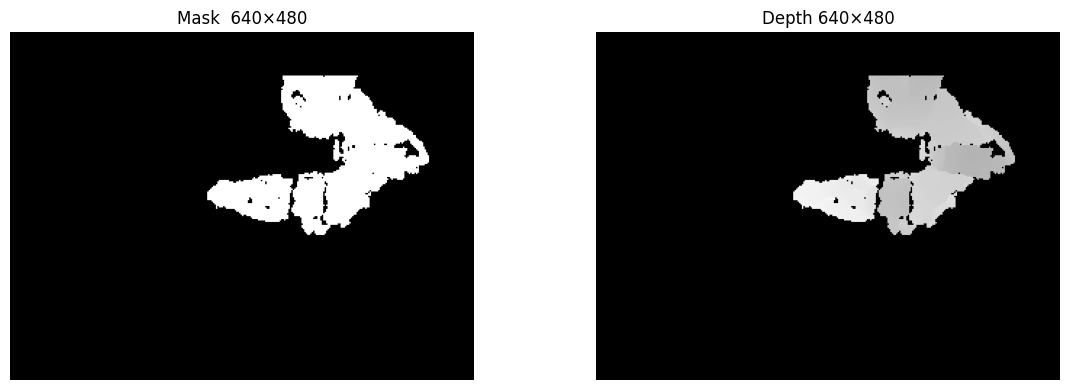

In [11]:
x0, mask0, depth0 = dataset[0]
print("x shape   :", x0.shape)
print("mask shape :", mask0.shape, " min/max:", mask0.min().item(), mask0.max().item())
print("depth shape:", depth0.shape, " min/max:", depth0.min().item(), depth0.max().item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(mask0.squeeze(), cmap="gray");  axes[0].set_title(f"Mask  {OUT_W}×{OUT_H}");  axes[0].axis("off")
axes[1].imshow(depth0.squeeze(), cmap="gray"); axes[1].set_title(f"Depth {OUT_W}×{OUT_H}"); axes[1].axis("off")
plt.tight_layout(); plt.show()

In [12]:
def split_indices(n: int, val_ratio: float, seed: int) -> Tuple[List[int], List[int]]:
    idxs = list(range(n))
    rng  = random.Random(seed)
    rng.shuffle(idxs)
    n_val = max(1, int(n * val_ratio))
    return idxs[n_val:], idxs[:n_val]


train_idxs, val_idxs = split_indices(len(dataset), VAL_RATIO, SEED)

train_subset = torch.utils.data.Subset(dataset, train_idxs)
val_subset   = torch.utils.data.Subset(dataset, val_idxs)

print("Train samples:", len(train_subset))
print("Val samples:  ", len(val_subset))

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True,
)
val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

xb, ymb, ydb = next(iter(train_loader))
print("xb:", xb.shape, "| ymb:", ymb.shape, "| ydb:", ydb.shape)

Train samples: 261
Val samples:   65
Train batches: 65  |  Val batches: 17


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


xb: torch.Size([4, 53]) | ymb: torch.Size([4, 1, 480, 640]) | ydb: torch.Size([4, 1, 480, 640])


In [13]:
class CoordConv2d(nn.Module):
    """Conv2d that appends normalised (y, x) coordinate channels before the conv."""

    def __init__(self, in_channels: int, out_channels: int, **kwargs) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels + 2, out_channels, **kwargs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, _, h, w = x.shape
        ys = torch.linspace(-1.0, 1.0, h, device=x.device).view(1, 1, h, 1).expand(b, 1, h, w)
        xs = torch.linspace(-1.0, 1.0, w, device=x.device).view(1, 1, 1, w).expand(b, 1, h, w)
        return self.conv(torch.cat([x, ys, xs], dim=1))


class JointToMaskDepthNet(nn.Module):
    """MLP → CoordConv decoder → (480, 640) mask + depth.

    The decoder upsamples from 8×8 to DECODER_SIZE×DECODER_SIZE (a square
    power-of-2), then a final F.interpolate maps to the exact (out_h, out_w).
    This lets the network train at any non-square / non-power-of-2 resolution.
    """

    def __init__(self, input_dim: int, out_h: int = 480, out_w: int = 640,
                 decoder_size: int = 256) -> None:
        super().__init__()
        assert decoder_size in (64, 128, 256, 512), \
            "decoder_size must be one of [64, 128, 256, 512]."
        self.out_h        = out_h
        self.out_w        = out_w
        self.decoder_size = decoder_size

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 8 * 8 * 128),
            nn.ReLU(inplace=True),
        )

        # Decoder: 8×8 → decoder_size×decoder_size via repeated ×2 upsample
        layers: List[nn.Module] = []
        in_ch    = 128
        cur_size = 8
        while cur_size < decoder_size:
            out_ch = max(in_ch // 2, 16)
            layers += [
                nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
                CoordConv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch     = out_ch
            cur_size *= 2

        self.shared_decoder = nn.Sequential(*layers)

        self.mask_head = CoordConv2d(in_ch, 1, kernel_size=1)
        self.depth_head = nn.Sequential(
            CoordConv2d(in_ch, in_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor):
        b    = x.shape[0]
        z    = self.mlp(x).view(b, 128, 8, 8)
        feat = self.shared_decoder(z)          # (B, C, decoder_size, decoder_size)

        mask_logits = self.mask_head(feat)     # (B, 1, decoder_size, decoder_size)
        depth_pred  = self.depth_head(feat)    # (B, 1, decoder_size, decoder_size)

        # Stretch to target resolution
        mask_logits = F.interpolate(mask_logits, size=(self.out_h, self.out_w),
                                    mode="bilinear", align_corners=False)
        depth_pred  = F.interpolate(depth_pred,  size=(self.out_h, self.out_w),
                                    mode="bilinear", align_corners=False)
        return mask_logits, depth_pred

In [14]:
model = JointToMaskDepthNet(
    input_dim=FEATURE_DIM,
    out_h=OUT_H,
    out_w=OUT_W,
    decoder_size=DECODER_SIZE,
).to(DEVICE)

with torch.no_grad():
    _test_x = torch.zeros(1, FEATURE_DIM).to(DEVICE)
    _ml, _dp = model(_test_x)
    print("mask_logits:", _ml.shape)   # expect (1, 1, 480, 640)
    print("depth_pred: ", _dp.shape)   # expect (1, 1, 480, 640)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {n_params:,}")

mask_logits: torch.Size([1, 1, 480, 640])
depth_pred:  torch.Size([1, 1, 480, 640])
Trainable params: 4,454,948


In [15]:
def dice_loss_from_logits(logits: torch.Tensor, targets: torch.Tensor,
                          eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    num   = 2.0 * (probs * targets).sum(dim=(1, 2, 3))
    den   = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + eps
    return 1.0 - (num / den).mean()


def mask_loss_fn(mask_logits, gt_mask):
    return (F.binary_cross_entropy_with_logits(mask_logits, gt_mask)
            + dice_loss_from_logits(mask_logits, gt_mask))


def depth_loss_fn(depth_pred, gt_depth, gt_mask):
    valid = gt_mask > 0.5
    if valid.sum() == 0:
        return torch.tensor(0.0, device=depth_pred.device)
    return F.smooth_l1_loss(depth_pred[valid], gt_depth[valid])


def total_loss_fn(mask_logits, depth_pred, gt_mask, gt_depth):
    l_mask  = mask_loss_fn(mask_logits, gt_mask)
    l_depth = depth_loss_fn(depth_pred, gt_depth, gt_mask)
    total   = MASK_LOSS_WEIGHT * l_mask + DEPTH_LOSS_WEIGHT * l_depth
    return total, l_mask.detach(), l_depth.detach()


@torch.no_grad()
def batch_iou_from_logits(logits, targets, thresh: float = 0.5,
                           eps: float = 1e-6) -> float:
    preds = (torch.sigmoid(logits) > thresh).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = ((preds + targets) > 0).float().sum(dim=(1, 2, 3)) + eps
    return (inter / union).mean().item()


@torch.no_grad()
def batch_depth_mae(depth_pred, gt_depth, gt_mask) -> float:
    valid = gt_mask > 0.5
    if valid.sum() == 0:
        return 0.0
    return float(torch.abs(depth_pred[valid] - gt_depth[valid]).mean().item())

In [16]:
def freeze_for_finetune(model: JointToMaskDepthNet) -> None:
    if FREEZE_MLP:
        for p in model.mlp.parameters():
            p.requires_grad = False
    if FREEZE_SHARED_DECODER:
        for p in model.shared_decoder.parameters():
            p.requires_grad = False


def save_checkpoint(path, model, optimizer, scheduler, epoch,
                    best_val_score) -> None:
    torch.save(
        {
            "epoch": epoch,
            "best_val_score": best_val_score,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": (scheduler.state_dict()
                                     if scheduler is not None else None),
            "input_dim": FEATURE_DIM,
            "out_h": OUT_H,
            "out_w": OUT_W,
            "decoder_size": DECODER_SIZE,
            "selected_joints": SELECTED_JOINTS,
            "use_velocities": USE_VELOCITIES,
            "use_efforts": USE_EFFORTS,
            "use_t_cam_to_ee": USE_T_CAM_TO_EE,
            "use_t_base_to_ee": USE_T_BASE_TO_EE,
            "depth_norm_mode": DEPTH_NORM_MODE,
            "depth_max_mm": DEPTH_MAX_MM,
            "mask_loss_weight": MASK_LOSS_WEIGHT,
            "depth_loss_weight": DEPTH_LOSS_WEIGHT,
            "session_roots": [str(s) for s in SESSION_ROOTS],
            "architecture": "coordconv",
        },
        path,
    )


def load_checkpoint_if_available(checkpoint_path, model, optimizer,
                                  scheduler, fine_tune, strict):
    start_epoch    = 1
    best_val_score = -1.0

    if not checkpoint_path:
        print("[INFO] Training from scratch.")
        return start_epoch, best_val_score

    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        print(f"[WARN] Checkpoint not found: {checkpoint_path} — from scratch.")
        return start_epoch, best_val_score

    print(f"[INFO] Loading checkpoint: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)

    model.load_state_dict(ckpt.get("model_state_dict", ckpt), strict=strict)

    if fine_tune:
        print("[INFO] Fine-tune mode: weights only.")
        return 1, best_val_score

    if "optimizer_state_dict" in ckpt:
        try:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        except Exception as e:
            print(f"[WARN] Could not load optimizer state: {e}")

    if scheduler is not None and ckpt.get("scheduler_state_dict") is not None:
        try:
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        except Exception as e:
            print(f"[WARN] Could not load scheduler state: {e}")

    start_epoch    = int(ckpt.get("epoch", 0)) + 1
    best_val_score = float(ckpt.get("best_val_score", -1.0))
    print(f"[INFO] Resume epoch: {start_epoch}, best_val_score: {best_val_score:.4f}")
    return start_epoch, best_val_score

In [17]:
@torch.no_grad()
def show_preview(model: nn.Module, subset, idx: int = 0) -> None:
    model.eval()
    x, y_mask, y_depth = subset[idx]
    mask_logits, depth_pred = model(x.unsqueeze(0).to(DEVICE))

    pred_mask     = torch.sigmoid(mask_logits)[0, 0].cpu().numpy()
    pred_depth    = depth_pred[0, 0].cpu().numpy()
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)
    pred_depth_m  = pred_depth.copy()
    pred_depth_m[pred_mask_bin == 0] = 0.0

    gt_mask  = y_mask[0].cpu().numpy()
    gt_depth = y_depth[0].cpu().numpy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].imshow(gt_mask,       cmap="gray"); axes[0, 0].set_title("GT mask");          axes[0, 0].axis("off")
    axes[0, 1].imshow(pred_mask_bin, cmap="gray"); axes[0, 1].set_title("Pred mask");         axes[0, 1].axis("off")
    axes[1, 0].imshow(gt_depth,      cmap="gray"); axes[1, 0].set_title("GT depth");          axes[1, 0].axis("off")
    axes[1, 1].imshow(pred_depth_m,  cmap="gray"); axes[1, 1].set_title("Pred depth (masked)"); axes[1, 1].axis("off")
    plt.tight_layout(); plt.show()

In [18]:
model = JointToMaskDepthNet(
    input_dim=FEATURE_DIM,
    out_h=OUT_H,
    out_w=OUT_W,
    decoder_size=DECODER_SIZE,
).to(DEVICE)

if FINE_TUNE:
    freeze_for_finetune(model)
    print(f"[INFO] Fine-tune freeze: MLP={FREEZE_MLP}, Decoder={FREEZE_SHARED_DECODER}")

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE
)
scheduler = None

start_epoch, best_val_score = load_checkpoint_if_available(
    checkpoint_path=RESUME_CHECKPOINT,
    model=model, optimizer=optimizer, scheduler=scheduler,
    fine_tune=FINE_TUNE, strict=STRICT_LOAD,
)
print("start_epoch:", start_epoch)
print("best_val_score:", best_val_score)

[INFO] Training from scratch.
start_epoch: 1
best_val_score: -1.0


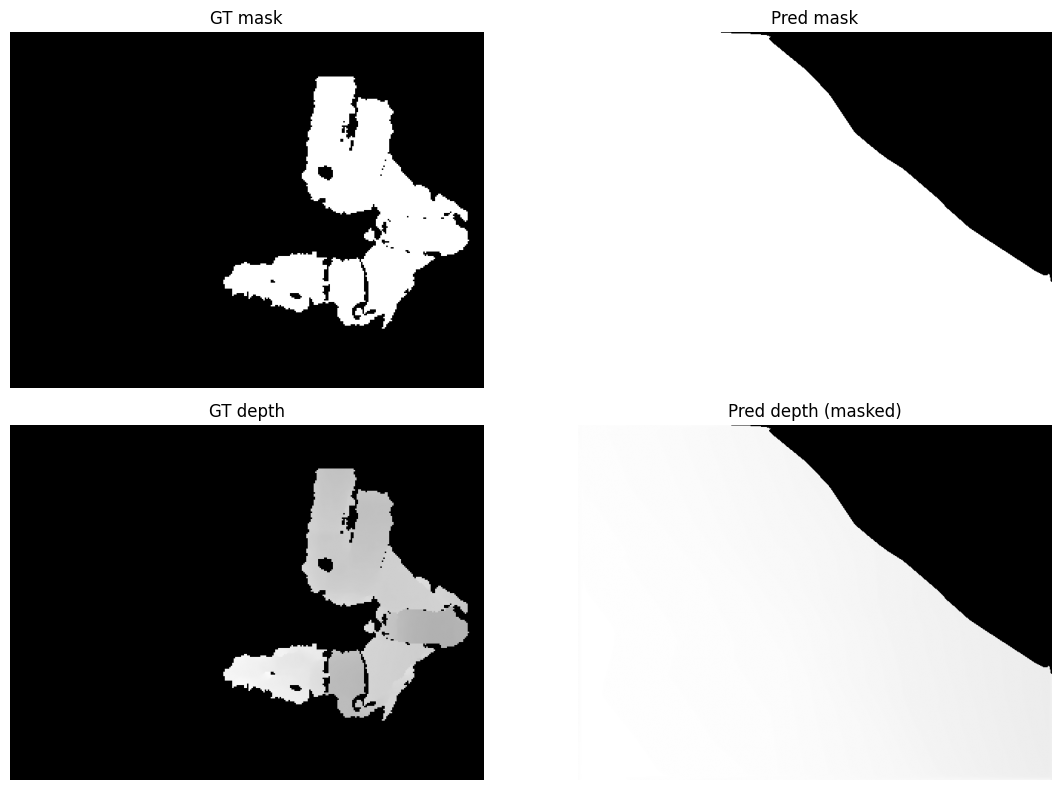

In [19]:
show_preview(model, val_subset, idx=0)

In [20]:
def evaluate(model: nn.Module, loader: DataLoader) -> Dict:
    model.eval()
    losses, mask_losses, depth_losses, ious, maes = [], [], [], [], []
    with torch.no_grad():
        for x, y_mask, y_depth in loader:
            x, y_mask, y_depth = x.to(DEVICE), y_mask.to(DEVICE), y_depth.to(DEVICE)
            mask_logits, depth_pred = model(x)
            loss, l_mask, l_depth = total_loss_fn(mask_logits, depth_pred, y_mask, y_depth)
            losses.append(loss.item())
            mask_losses.append(l_mask.item())
            depth_losses.append(l_depth.item())
            ious.append(batch_iou_from_logits(mask_logits, y_mask))
            maes.append(batch_depth_mae(depth_pred, y_depth, y_mask))
    return {
        "loss":       float(np.mean(losses)),
        "mask_loss":  float(np.mean(mask_losses)),
        "depth_loss": float(np.mean(depth_losses)),
        "iou":        float(np.mean(ious)),
        "depth_mae":  float(np.mean(maes)),
    }


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer) -> Dict:
    model.train()
    losses, mask_losses, depth_losses, ious, maes = [], [], [], [], []
    for x, y_mask, y_depth in loader:
        x, y_mask, y_depth = x.to(DEVICE), y_mask.to(DEVICE), y_depth.to(DEVICE)
        optimizer.zero_grad()
        mask_logits, depth_pred = model(x)
        loss, l_mask, l_depth = total_loss_fn(mask_logits, depth_pred, y_mask, y_depth)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        mask_losses.append(l_mask.item())
        depth_losses.append(l_depth.item())
        ious.append(batch_iou_from_logits(mask_logits.detach(), y_mask))
        maes.append(batch_depth_mae(depth_pred.detach(), y_depth, y_mask))
    return {
        "loss":       float(np.mean(losses)),
        "mask_loss":  float(np.mean(mask_losses)),
        "depth_loss": float(np.mean(depth_losses)),
        "iou":        float(np.mean(ious)),
        "depth_mae":  float(np.mean(maes)),
    }

In [21]:
history = []
CHECKPOINT_DIR.mkdir(exist_ok=True)
no_improve = 0

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    train_stats = train_one_epoch(model, train_loader, optimizer)
    val_stats   = evaluate(model, val_loader)

    val_score  = val_stats["iou"] - val_stats["depth_mae"]
    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch, "lr": current_lr,
        **{f"train_{k}": v for k, v in train_stats.items()},
        **{f"val_{k}":   v for k, v in val_stats.items()},
        "val_score": val_score,
    }
    history.append(row)

    print(
        f"[Epoch {epoch:03d}] lr={current_lr:.6f} "
        f"train_loss={row['train_loss']:.4f} train_iou={row['train_iou']:.4f} "
        f"train_depth_mae={row['train_depth_mae']:.4f} | "
        f"val_loss={row['val_loss']:.4f} val_iou={row['val_iou']:.4f} "
        f"val_depth_mae={row['val_depth_mae']:.4f} val_score={val_score:.4f}"
    )

    save_checkpoint(
        path=CHECKPOINT_DIR / "latest_multisession_640x480.pth",
        model=model, optimizer=optimizer, scheduler=scheduler,
        epoch=epoch, best_val_score=best_val_score,
    )

    if val_score > best_val_score:
        best_val_score = val_score
        no_improve = 0
        save_checkpoint(
            path=CHECKPOINT_DIR / "best_multisession_640x480.pth",
            model=model, optimizer=optimizer, scheduler=scheduler,
            epoch=epoch, best_val_score=best_val_score,
        )
        print(f"  [INFO] New best saved: val_score={best_val_score:.4f}")
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f"[INFO] Early stopping after {EARLY_STOP_PATIENCE} epochs.")
            break

print("Training finished. Best val score:", best_val_score)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Epoch 001] lr=0.001000 train_loss=5.4999 train_iou=0.5592 train_depth_mae=0.0404 | val_loss=4.7798 val_iou=0.6665 val_depth_mae=0.0194 val_score=0.6472
  [INFO] New best saved: val_score=0.6472
[Epoch 002] lr=0.001000 train_loss=3.9331 train_iou=0.7646 train_depth_mae=0.0211 | val_loss=3.3718 val_iou=0.8221 val_depth_mae=0.0215 val_score=0.8007
  [INFO] New best saved: val_score=0.8007
[Epoch 003] lr=0.001000 train_loss=2.7734 train_iou=0.8388 train_depth_mae=0.0185 | val_loss=2.3116 val_iou=0.8524 val_depth_mae=0.0140 val_score=0.8384
  [INFO] New best saved: val_score=0.8384
[Epoch 004] lr=0.001000 train_loss=2.0024 train_iou=0.8460 train_depth_mae=0.0173 | val_loss=1.8092 val_iou=0.8069 val_depth_mae=0.0186 val_score=0.7883
[Epoch 005] lr=0.001000 train_loss=1.5448 train_iou=0.8459 train_depth_mae=0.0166 | val_loss=1.3027 val_iou=0.8683 val_depth_mae=0.0157 val_score=0.8525
  [INFO] New best saved: val_score=0.8525
[Epoch 006] lr=0.001000 train_loss=1.1590 train_iou=0.8694 train_de

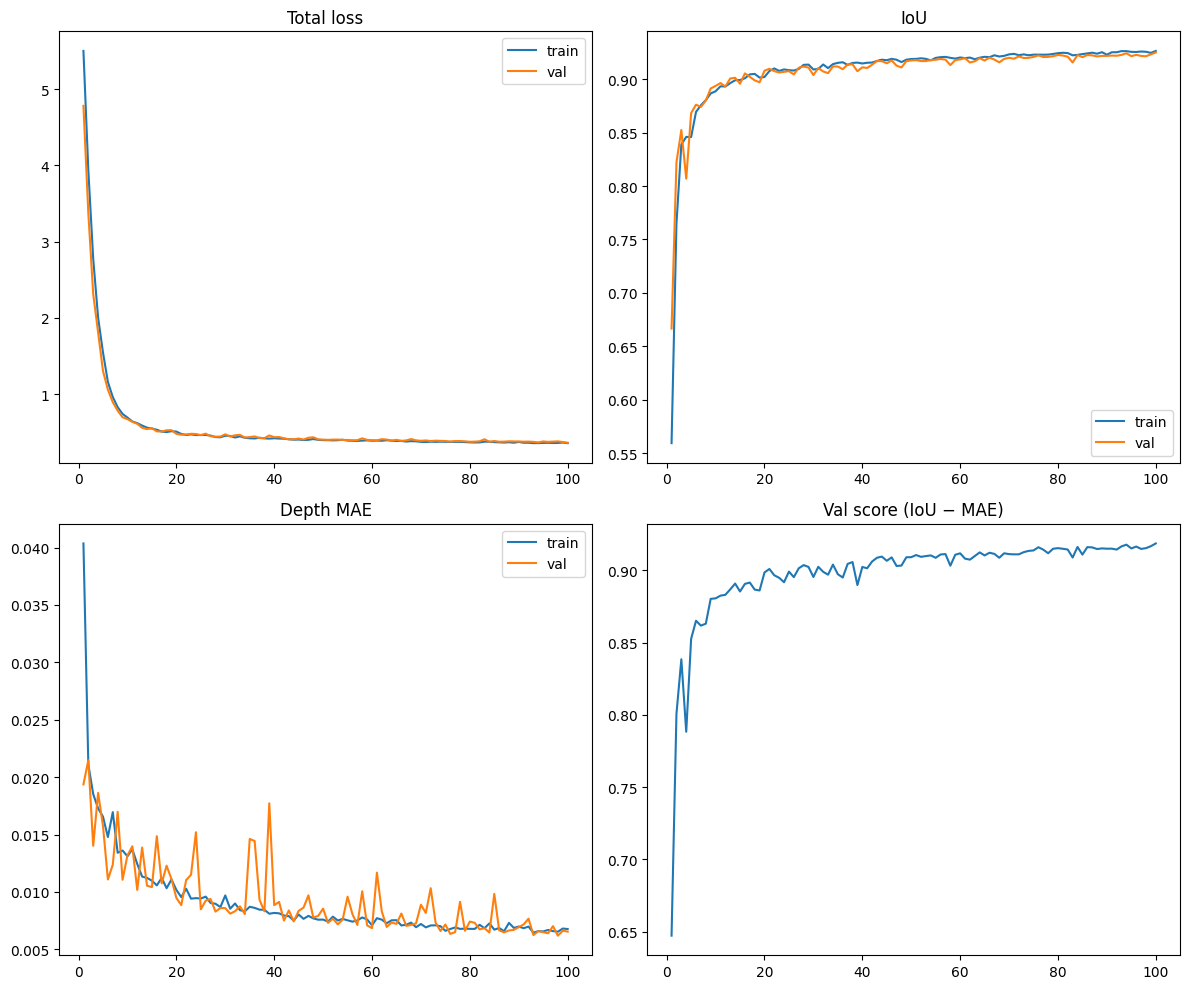

In [22]:
if history:
    epochs = [h["epoch"] for h in history]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].plot(epochs, [h["train_loss"] for h in history], label="train")
    axes[0, 0].plot(epochs, [h["val_loss"]   for h in history], label="val")
    axes[0, 0].set_title("Total loss"); axes[0, 0].legend()

    axes[0, 1].plot(epochs, [h["train_iou"] for h in history], label="train")
    axes[0, 1].plot(epochs, [h["val_iou"]   for h in history], label="val")
    axes[0, 1].set_title("IoU"); axes[0, 1].legend()

    axes[1, 0].plot(epochs, [h["train_depth_mae"] for h in history], label="train")
    axes[1, 0].plot(epochs, [h["val_depth_mae"]   for h in history], label="val")
    axes[1, 0].set_title("Depth MAE"); axes[1, 0].legend()

    axes[1, 1].plot(epochs, [h["val_score"] for h in history])
    axes[1, 1].set_title("Val score (IoU − MAE)")

    plt.tight_layout(); plt.show()
else:
    print("No history yet. Run training first.")

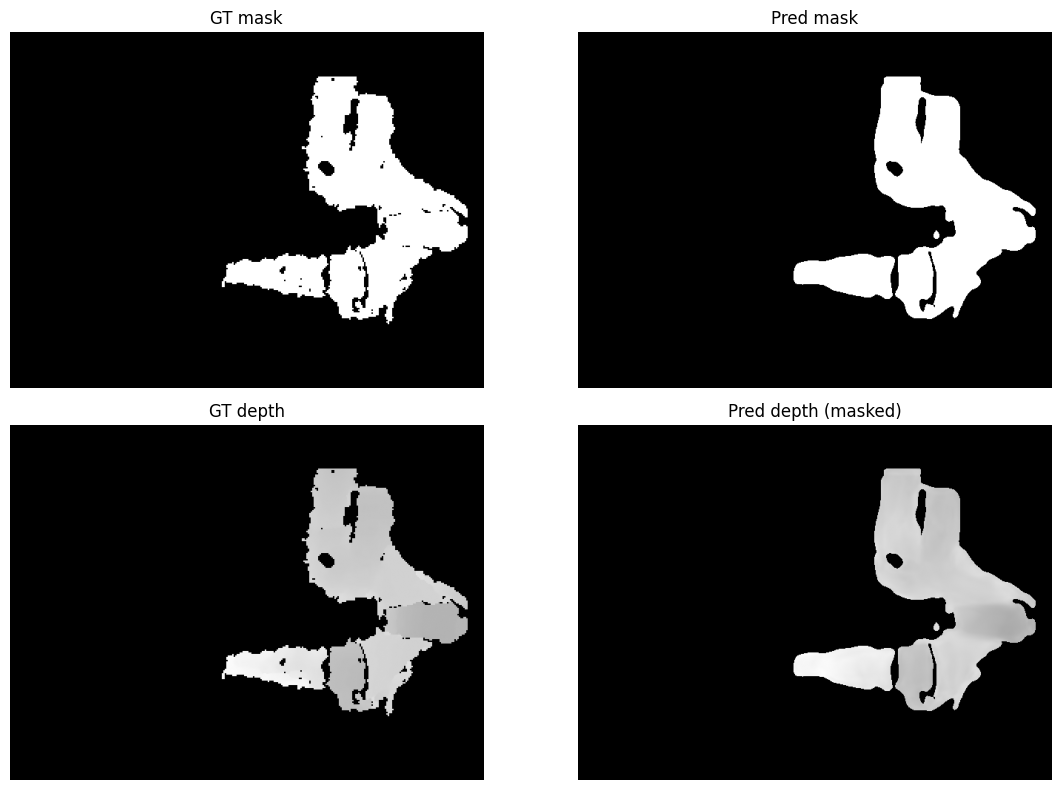

In [23]:
show_preview(model, val_subset, idx=6)

In [24]:
import json as _json

history_path = CHECKPOINT_DIR / "training_history_multisession_640x480.json"
with open(history_path, "w", encoding="utf-8") as f:
    _json.dump(history, f, indent=2)
print("Saved history to", history_path)

#v1

Saved history to /content/checkpoints_multisession_640x480/training_history_multisession_640x480.json
